# Ensemble Structure Function Estimation for Simulated AGN Light Curves

## 1. Overview and Required Packages

This notebook illustrates how to use the `agnsf` package to compute ensemble structure functions (ESF).

We will:

1. Simulate a mock ensemble of several **DRW** light curves, each with its own randomly drawn parameters.
2. Compute three different flavours of the ESF:
   - ESF = $\sqrt{\left<\mathrm{SF}^2\right>}$
   - ESF = $\left<\mathrm{SF}\right>$
   - Pooled $\mathrm{SF}$

We need the following packages:

- numpy
- matplotlib
- agnsf
- astroML

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import agnsf

# python -m pip install astroML
from astroML.time_series import generate_damped_RW

## 2. Simulation Parameters
Here we define the basic settings for our mock data set.

In [2]:
n_sources = 1000 # number of independent LCs to generate
n_points = 25 # number of observations per LC

# the time baseline of each LC (in days)
t_min = 0.0
t_max = 2500.0

# the constant measurement error
obs_err = 0.1

# a fixed random seed for reproducible results
rng = np.random.RandomState(42)

## 3. Hyper‑parameters of the DRW Population

Each light curve is generated from a DRW process, which is governed by four parameters:

- $\tau$ — damping time scale, in days
- $z$ — redshift
- $\left<x\right>$ — the mean magnitude of the source
- $\mathrm{SF}_{\infty}$ — structure function amplitude at infinite lag

We assume that these parameters follow a **population distribution** (given in the `population` dictionary). For example, $\tau$ and $\mathrm{SF}_{\infty}$ are log‑normal, $z$ is uniform, and $\left<x\right>$ is Gaussian.

In [3]:
population = {
    # tau [day]
    "tau": {
        "distribution": "lognormal",
        "log10_mean": np.log10(1000.0),
        "log10_std": 0.3,
    },

    # redshift
    "z": {
        "distribution": "uniform",
        "min": 0.0,
        "max": 0.3,
    },

    # mean magnitude
    "xmean": {
        "distribution": "normal",
        "mean": 17.5,
        "std": 0.5,
    },

    # SFinf [mag]
    "SFinf": {
        "distribution": "lognormal",
        "log10_mean": np.log10(0.3),
        "log10_std": 0.2,
    },
}


## 4. Draw Individual Parameters for Each Source

In [4]:

tau_array = 10 ** rng.normal(
    population["tau"]["log10_mean"],
    population["tau"]["log10_std"],
    n_sources,
)

z_array = rng.uniform(
    population["z"]["min"],
    population["z"]["max"],
    n_sources,
)

xmean_array = rng.normal(
    population["xmean"]["mean"],
    population["xmean"]["std"],
    n_sources,
)

SFinf_array = 10 ** rng.normal(
    population["SFinf"]["log10_mean"],
    population["SFinf"]["log10_std"],
    n_sources,
)

## 5. Simulate Observed Light Curves

For each source, we generate random observation times, simulate a DRW light curve using its drawn parameters, assign a constant measurement error, and store all three arrays.

In [5]:
times_list = []
curves_list = []
errors_list = []

for i in range(n_sources):
    t = np.sort(
        rng.uniform(
            t_min,
            t_max,
            n_points,
        )
    )

    y = generate_damped_RW(
        t,
        tau=tau_array[i],
        z=z_array[i],
        xmean=xmean_array[i],
        SFinf=SFinf_array[i],
        random_state=rng,
    )

    err = np.full_like(y, obs_err)

    times_list.append(t)
    curves_list.append(y)
    errors_list.append(err)


## 6. Compute the Ensemble Structure Function

In [6]:
cfg = agnsf.UncertaintyConfig()
cfg.measurement = agnsf.UncertaintyMethod.Analytic
cfg.sampling    = agnsf.UncertaintyMethod.Bootstrap
cfg.n_bootstrap = 500
cfg.bootstrap_seed = 42

bins = agnsf.LagBins.logarithmic(150, 1500, 0.1)

In [7]:
# ESF = sqrt(<SF^2>)
result_rms = agnsf.ensemble_sf(
    times_list,
    curves_list,
    errors_list,
    bins,
    uncertainty=cfg
)

# ESF = <SF>
result_mean = agnsf.ensemble_sf(
    times_list,
    curves_list,
    errors_list,
    bins,
    agnsf.EnsembleMethod.MeanSf,
    uncertainty=cfg
)

# Pooled ESF
result_pool = agnsf.pooled_sf(
    times_list,
    curves_list,
    errors_list,
    bins,
    method=agnsf.SFMethod.MeanAbsoluteDeviationNoNoise,
    uncertainty=cfg
)

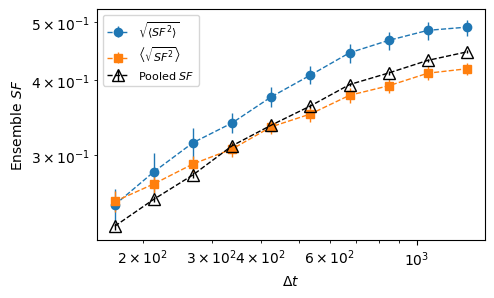

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3), dpi=100)

pars_rms = {
    "fmt": "o--",
    "label": "$\\sqrt{\\left<SF^2\\right>}$",
    "lw": 1
}

pars_mean = {
    "fmt": "s--",
    "label": "$\\left<\\sqrt{SF^2}\\right>$",
    "lw": 1
}

pars_pool = {
    "fmt": "^--",
    "label": "Pooled $SF$",
    "lw": 1,
    "markerfacecolor": "none",
    "c": "k",
    "ms": 8
}

for res, pars in [
    (result_rms,  pars_rms),
    (result_mean, pars_mean),
    (result_pool, pars_pool)
]:

    (tau,  esf,  _,  _, m_lo, m_up, s_lo, s_up) \
        = agnsf.to_numpy(res,  bins, uncertainty=True)

    em_lo = esf - m_lo
    em_up = m_up - esf
    es_lo = esf - s_lo
    es_up = s_up - esf

    e_lo = np.sqrt(em_lo**2 + es_lo**2)
    e_up = np.sqrt(em_up**2 + es_up**2)
    
    ax.errorbar(tau, esf, yerr=[e_lo, e_up], **pars)


ax.set_xlabel("$\\Delta t$")
ax.set_ylabel("Ensemble $SF$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8)
plt.show()